In [74]:
import xml.etree.ElementTree as ET
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import joblib  # Thư viện để lưu mô hình
import numpy as np  

In [75]:
plt.rcParams['figure.figsize'] = (10,8)
plt.rcParams['figure.dpi'] = 100 
plt.rcParams['font.size'] = 14 

In [76]:
tree = ET.parse('data/XeDaQuaSuDung.xml')
root = tree.getroot()

data = []
for xe in root.findall('xe'):
    data.append({
        'Hang_SX': xe.find('Hang_SX').text if xe.find('Hang_SX') is not None else None,
        'So_Km': float(xe.find('So_Km').text),
        'Nam_Su_Dung': float(xe.find('Nam_Su_Dung').text),
        'Gia_Xe': float(xe.find('Gia_Xe').text)
    })
df = pd.DataFrame(data)

In [77]:
tree

In [78]:
df

,Hang_SX,So_Km,Nam_Su_Dung,Gia_Xe
0,Audi,111.0,6.0,19.00
1,Audi,56.5,3.0,33.00
2,BMW,91.8,5.0,26.10
3,Audi,36.2,2.0,40.50
4,BMW,75.0,4.0,32.50
5,BMW,95.0,5.0,26.75
6,Audi,83.7,5.0,32.00
7,BMW,115.9,6.0,19.30
8,Audi,146.5,8.0,12.00
9,Audi,107.8,6.0,22.00


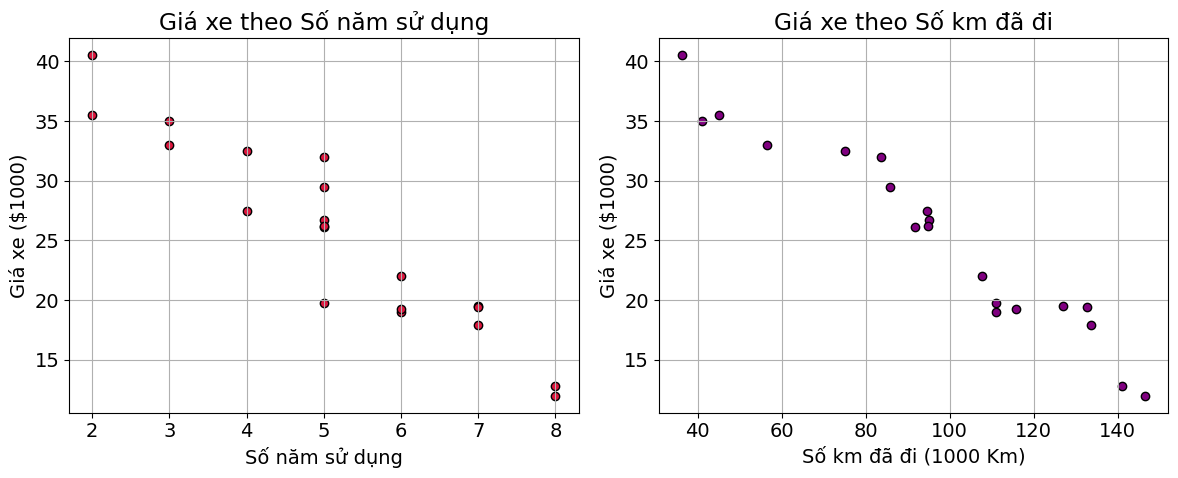

In [79]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.scatter(df['Nam_Su_Dung'], df['Gia_Xe'], color='crimson', edgecolors='black')
ax1.set_title('Giá xe theo Số năm sử dụng')
ax1.set_xlabel('Số năm sử dụng')
ax1.set_ylabel('Giá xe ($1000)')
ax1.grid(True)

ax2.scatter(df['So_Km'], df['Gia_Xe'], color='purple', edgecolors='black')
ax2.set_title('Giá xe theo Số km đã đi')
ax2.set_xlabel('Số km đã đi (1000 Km)')
ax2.set_ylabel('Giá xe ($1000)')
ax2.grid(True)
plt.tight_layout()
plt.show()

## Nhận xét : 
- Với Giá xe theo Số năm sử dụng thì nhận thấy rõ xu hướng giảm của giá xe khi số năm tăng.
- Với Giá xe với Số km đã đi cũng tương tự, xu hướng giảm khi Sô km đã đi tăng, nhưng độ phân tán ít hơn một chút só với biểu đồ giá với năm sử dụng 

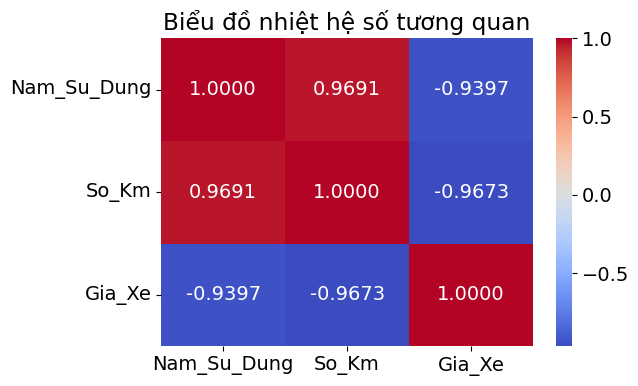

In [80]:
corr_matrix = df[['Nam_Su_Dung', 'So_Km', 'Gia_Xe']].corr()
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".4f")
plt.title('Biểu đồ nhiệt hệ số tương quan')
plt.show()


In [81]:
# x = df[['Nam_Su_Dung', 'So_Km']] # 0.936
# x = df[['Nam_Su_Dung']] # 0.883
x = df[['So_Km']] #  0.936

y = df['Gia_Xe'] 
x,y = np.array(x), np.array(y)
x = sm.add_constant(x)

In [82]:
model = sm.OLS(y, x)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.932
Method:                 Least Squares   F-statistic:                     261.8
Date:                Sat, 23 May 2026   Prob (F-statistic):           3.61e-12
Time:                        13:18:26   Log-Likelihood:                -41.755
No. Observations:                  20   AIC:                             87.51
Df Residuals:                      18   BIC:                             89.50
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         47.5550      1.450     32.804      0.0

## Giá = 47.5730 - -0.1617 * giá + -0.2225 * Quảng cáo  ( y = a + x1.b+ x2.b2  ) 
(Khi các yếu tố khác không đổi)
- 47.5730 gọi là hệ số chặn, là điểm mà đường hồi quy cắt trục y khi tất cả các biến bằng không. Có nghĩa là nếu giá trị của năm sử dụng và số km không tác động thì giá trị dự đoán sẽ là 47.5730
- -0.1617 , có nghĩa là nếu ta tăng năm sử dụng một đơn vị thì số giá bán giảm 0.1617 đơn vị.
- -0.2225 , có nghĩa là nếu ta tăng số km 1 đơn vị, giá bán tăng giảm 0.2225 đơn vị.

In [83]:
f_pvalue = results.f_pvalue
print(f_pvalue)

3.6096141223240032e-12


- Ho : năm sử dụng và số km không tác động đến lượng bán
- h1 : năm sử dụng và số km có tác động đến lượng bán
- ta nhận được p-value = 7.367599582279802e-11, cực kỳ nhỏ , gần như bằng 0 -> Với mức ý nghĩa 5% ta bác bỏ H0 và chấp nhận H1 rằng năm sử dụng và số km có tác động đến giá bán

In [84]:
R_2 = results.rsquared
print(R_2)

0.9356616866314731


- ta nhận được hệ số xác định là khoảng 0.93, nếu chỉ nhìn về mặt kỹ thuật ta nhận định rằng mô hình đáng tin cậy và phù hợp với dữ liệu huấn luyện, vì chỉ số cho biết được các biến độc lập giải thích được 93% sự biến động của biến phụ thuộc. 

In [87]:
data_pred = pd.DataFrame(
    {
        'Nam_su_dung': [ 6, 3],

    }
)

predicted_sales = results.predict(sm.add_constant(data_pred))
print(predicted_sales)

0    46.169170
1    46.862083
dtype: float64
